1. Loading data...
2. Aggregating status codes...

3. Splitting dataset...


/tmp/ipykernel_1489341/4119313663.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["status_grouped"] = df[TARGET_COL].map(status_group_mapping)



4. Calculating class weights...

5. Starting model training...
[0]	validation-logloss:0.68410	validation-auc:0.79672	train-logloss:0.68200	train-auc:0.79761
[50]	validation-logloss:0.50660	validation-auc:0.81782	train-logloss:0.48672	train-auc:0.81838
[100]	validation-logloss:0.48434	validation-auc:0.82458	train-logloss:0.46470	train-auc:0.82615
[150]	validation-logloss:0.47808	validation-auc:0.82928	train-logloss:0.45800	train-auc:0.83226
[200]	validation-logloss:0.47399	validation-auc:0.83342	train-logloss:0.45333	train-auc:0.83756
[250]	validation-logloss:0.47020	validation-auc:0.83708	train-logloss:0.44909	train-auc:0.84201
[300]	validation-logloss:0.46686	validation-auc:0.83970	train-logloss:0.44562	train-auc:0.84538
[350]	validation-logloss:0.46453	validation-auc:0.84175	train-logloss:0.44294	train-auc:0.84794
[400]	validation-logloss:0.46276	validation-auc:0.84324	train-logloss:0.44091	train-auc:0.84990
[450]	validation-logloss:0.46145	validation-auc:0.84426	train-logloss:0.439

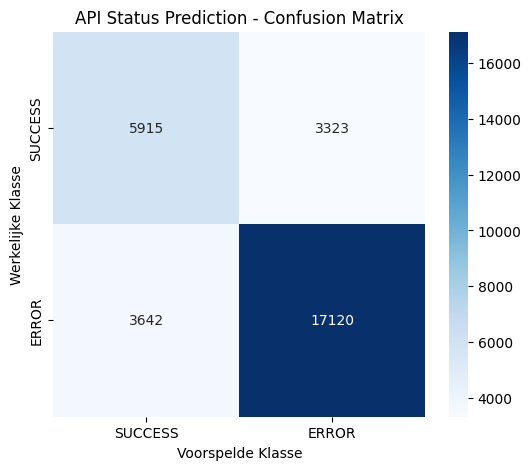


[INFO] Model exporteren naar best_api_xgboost_model.json...
[SUCCESS] Model succesvol opgeslagen! Bestandsgrootte: 7789.65 KB


In [4]:
"""
API Status Prediction Model using XGBoost.

This script processes structured log data, aggregates HTTP status codes into 
binary categories (SUCCESS vs. ERROR), and trains an XGBoost binary classifier.
Evaluation metrics include LogLoss, classification reports, and AUC-ROC scores.
"""
import os
import gc
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CONFIGURATION
# ==========================================
DATA_PATH = "transformed_data_sampled.csv"
TARGET_COL = "status"

# ==========================================
# 1. DATA INGESTION
# ==========================================
print("1. Loading data...")
sample = pd.read_csv(DATA_PATH, nrows=100)

dtypes = {}
for col in sample.columns:
    if sample[col].dtype == "float64":
        dtypes[col] = "float32"
    elif sample[col].dtype == "int64":
        dtypes[col] = "int32"
    else:
        dtypes[col] = sample[col].dtype

df = pd.read_csv(DATA_PATH, dtype=dtypes)

# ==========================================
# 2. STATUS CODE AGGREGATION & BINARIZATION
# ==========================================
print("2. Aggregating status codes...")
status_group_mapping = {
    0: "SUCCESS",        # 200
    1: "SUCCESS",        # 201
    2: "SUCCESS",        # 204
    3: "ERROR",          # 400
    4: "ERROR",          # 401
    5: "ERROR",          # 404
    6: "ERROR"           # 500
}

df["status_grouped"] = df[TARGET_COL].map(status_group_mapping)

# ERROR = 1 (Positieve klasse), SUCCESS = 0 (Negatieve klasse)
binary_mapping = {"SUCCESS": 0, "ERROR": 1}
df[TARGET_COL] = df["status_grouped"].map(binary_mapping)
df.drop(columns=["status_grouped"], inplace=True)

# ==========================================
# 3. FEATURE / TARGET SPLIT
# ==========================================
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]
del df
gc.collect()

# ==========================================
# 4. TRAIN / VALIDATION SPLIT
# ==========================================
print("\n3. Splitting dataset...")
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

num_classes = len(np.unique(y_train))
del X, y
gc.collect()

# ==========================================
# 5. CLASS WEIGHTS BEREKENEN
# ==========================================
print("\n4. Calculating class weights...")
class_counts = y_train.value_counts().sort_index()
class_weights = {
    cls: len(y_train) / (len(class_counts) * count)
    for cls, count in class_counts.items()
}

sample_weights = y_train.map(class_weights).values

# ==========================================
# 6. DMATRIX CONVERSION
# ==========================================
dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
dval = xgb.DMatrix(X_val, label=y_val)

# ==========================================
# 7. HYPERPARAMETERS (with AUC evaluation)
# ==========================================
params = {
    "objective": "binary:logistic", 
    "tree_method": "hist",
    "max_depth": 6,
    "min_child_weight": 5,
    "learning_rate": 0.05,
    
    # Multiple evaluation metrics specified as a list
    "eval_metric": ["logloss", "auc"], 

    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "max_delta_step": 1,
    "verbosity": 1
}

# ==========================================
# 8. MODEL TRAINING
# ==========================================
print("\n5. Starting model training...")
evallist = [(dval, "validation"), (dtrain, "train")]
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=evallist,            
    early_stopping_rounds=50,
    verbose_eval=50
)

# ==========================================
# 9. EVALUATION
# ==========================================
print("\n=== EVALUATION ===")


preds_prob = bst.predict(dval)


y_pred = (preds_prob >= 0.35).astype(int)

# Berekening AUC-ROC blijft perfect zo:
auc_score = roc_auc_score(y_val, preds_prob)
print(f"Final AUC-ROC Score: {auc_score:.4f}")
print("-" * 40)

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=["SUCCESS", "ERROR"]))

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True,          
    fmt='d',             
    cmap='Blues',        
    xticklabels=['SUCCESS', 'ERROR'], 
    yticklabels=['SUCCESS', 'ERROR']
)

plt.ylabel('Werkelijke Klasse')
plt.xlabel('Voorspelde Klasse')
plt.title('API Status Prediction - Confusion Matrix')
plt.savefig('Confusion_Matrix.png')
plt.show()

import os

def export_best_model(model, file_path="best_api_xgboost_model.json"):
    """
    Exporteert het getrainde XGBoost model naar de schijf.
    """
    try:
        print(f"\n[INFO] Model exporteren naar {file_path}...")
        
        # Sla het model op in het native XGBoost JSON-formaat
        model.save_model(file_path)
        
        if os.path.exists(file_path):
            print(f"[SUCCESS] Model succesvol opgeslagen! Bestandsgrootte: {os.path.getsize(file_path) / 1024:.2f} KB")
        else:
            print("[WARNING] Export voltooid, maar bestand kon niet worden geverifieerd.")
            
    except Exception as e:
        print(f"[ERROR] Fout opgetreden tijdens het exporteren van het model: {e}")


export_best_model(bst)

In [5]:
# Train een mini-model met 5 bomen om de belangrijkste feature te vinden
mini_bst = xgb.train(params, dtrain, num_boost_round=5)
importance = mini_bst.get_score(importance_type="gain")
print("Belangrijkste features:", sorted(importance.items(), key=lambda x: x[1], reverse=True)[:3])


Belangrijkste features: [('type_GET', 18986.970703125), ('body_MISSING', 900.24169921875), ('runid', 146.27378845214844)]
